# Exploración de Datos Fundamentales — 5 Empresas BVL

Visualización del pipeline R4: indicadores fundamentales trimestrales obtenidos
del web service SOAP de Datos Abiertos de la SMV (2005-Q1 a 2025-Q4). Incluye
acciones en circulación, EPS TTM y los ratios de valoración **P/E** y **DY**
(ver secciones 5b y docs/pipeline §3.10.2).

| Ticker | Empresa | Sector | Moneda |
|--------|---------|--------|--------|
| CREDITC1 | Banco de Crédito del Perú | Banca | PEN |
| BUENAVC1 | Cía. de Minas Buenaventura | Minería | USD |
| ALICORC1 | Alicorp | Alimentos | PEN |
| SAGAC1 | Saga Falabella | Retail | PEN |
| CORAREC1 | Aceros Arequipa | Manufactura | PEN |

> **Nota metodológica:** Los montos están en **miles** de la unidad monetaria (`value` = miles de PEN o miles de USD). `known_date` es la fecha de publicación efectiva (cierre del trimestre + 45 días de lag conservador), usada para evitar *look-ahead bias* al entrenar el modelo DRL.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_RAW = pathlib.Path('../data/raw')

TICKERS = ['CREDITC1', 'BUENAVC1', 'ALICORC1', 'SAGAC1', 'CORAREC1']
NOMBRES = {
    'CREDITC1': 'BCP',
    'BUENAVC1': 'Buenaventura',
    'ALICORC1': 'Alicorp',
    'SAGAC1':   'Saga Falabella',
    'CORAREC1': 'Aceros Arequipa',
}
SECTORES = {
    'CREDITC1': 'Banca',
    'BUENAVC1': 'Minería (USD)',
    'ALICORC1': 'Alimentos',
    'SAGAC1':   'Retail',
    'CORAREC1': 'Manufactura',
}
COLORES = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
COLOR_MAP = dict(zip(TICKERS, COLORES))

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})

## 1. Carga de datos

In [2]:
from src.fundamentals.fundamentals_client import compute_ratios
from src.universe import Config

ASSETS = {a.bvl: a for a in Config.load('../config.yaml').assets}

fund, ratio_list = {}, []
for ticker in TICKERS:
    p = DATA_RAW / f'fund_{ticker}_smv.parquet'
    if p.exists():
        fund[ticker] = pd.read_parquet(p)
        df_t = fund[ticker]
        # asset=... añade shares_outstanding, net_income_ttm y eps_ttm (insumos P/E)
        ratio_list.append(compute_ratios(df_t, asset=ASSETS[ticker]))
        print(f'✓ {ticker}: {len(df_t)} filas, '
              f'{df_t["period"].nunique()} periodos, '
              f'moneda={df_t["currency"].unique().tolist()}')
    else:
        print(f'✗ {ticker}: no encontrado — ejecutar scripts/fetch_fund_extended.py')

all_fund = pd.concat(list(fund.values()), ignore_index=True)
all_fund['period'] = pd.to_datetime(all_fund['period'])

ratios = pd.concat(ratio_list, ignore_index=True)
ratios['period'] = pd.to_datetime(ratios['period'])
print(f'\nRatios calculados: {len(ratios)} filas, columnas={list(ratios.columns)}')

✓ CREDITC1: 22425 filas, 83 periodos, moneda=['PEN']
✓ BUENAVC1: 17928 filas, 84 periodos, moneda=['PEN', 'USD']
✓ ALICORC1: 17928 filas, 84 periodos, moneda=['PEN', 'USD']


✓ SAGAC1: 17928 filas, 84 periodos, moneda=['PEN']
✓ CORAREC1: 17924 filas, 84 periodos, moneda=['PEN']

Ratios calculados: 419 filas, columnas=['ticker', 'period', 'known_date', 'currency', 'roe', 'roa', 'net_margin', 'debt_equity', 'debt_ratio', 'shares_outstanding', 'net_income_ttm', 'eps_ttm']


## 2. Resumen estadístico

In [3]:
resumen = []
for ticker, df in fund.items():
    r = ratios[ratios['ticker'] == ticker]
    resumen.append({
        'Ticker':   ticker,
        'Empresa':  NOMBRES[ticker],
        'Sector':   SECTORES[ticker],
        'Periodos': df['period'].nunique(),
        'Desde':    df['period'].min(),
        'Hasta':    df['period'].max(),
        'Cuentas':  df['account'].nunique(),
        'Moneda':   df['currency'].iloc[0],
        'ROE (ult)': r['roe'].iloc[-1].round(4) if len(r) else None,
        'ROA (ult)': r['roa'].iloc[-1].round(4) if len(r) else None,
    })

df_res = pd.DataFrame(resumen).set_index('Ticker')
df_res

,Empresa,Sector,Periodos,Desde,Hasta,Cuentas,Moneda,ROE (ult),ROA (ult)
Ticker,,,,,,,,,
CREDITC1,BCP,Banca,83,2005-03-31,2025-12-31,443,PEN,0.0582,0.0078
BUENAVC1,Buenaventura,Minería (USD),84,2005-03-31,2025-12-31,398,PEN,0.0944,0.0725
ALICORC1,Alicorp,Alimentos,84,2005-03-31,2025-12-31,398,PEN,-0.0486,-0.0072
SAGAC1,Saga Falabella,Retail,84,2005-03-31,2025-12-31,398,PEN,0.1794,0.0503
CORAREC1,Aceros Arequipa,Manufactura,84,2005-03-31,2025-12-31,397,PEN,0.0187,0.0098


## 3. Estructura del Balance — Activo, Pasivo y Patrimonio

Las barras apiladas muestran cómo se financia el activo total (pasivo en rojo, patrimonio en azul). La línea discontinua confirma que Activo = Pasivo + Patrimonio (identidad contable).

> **BCP** es un banco: su ratio D/E estructuralmente alto (~7-9×) es normal en la industria financiera (los depósitos son pasivo). No es comparable directamente con las empresas no financieras.

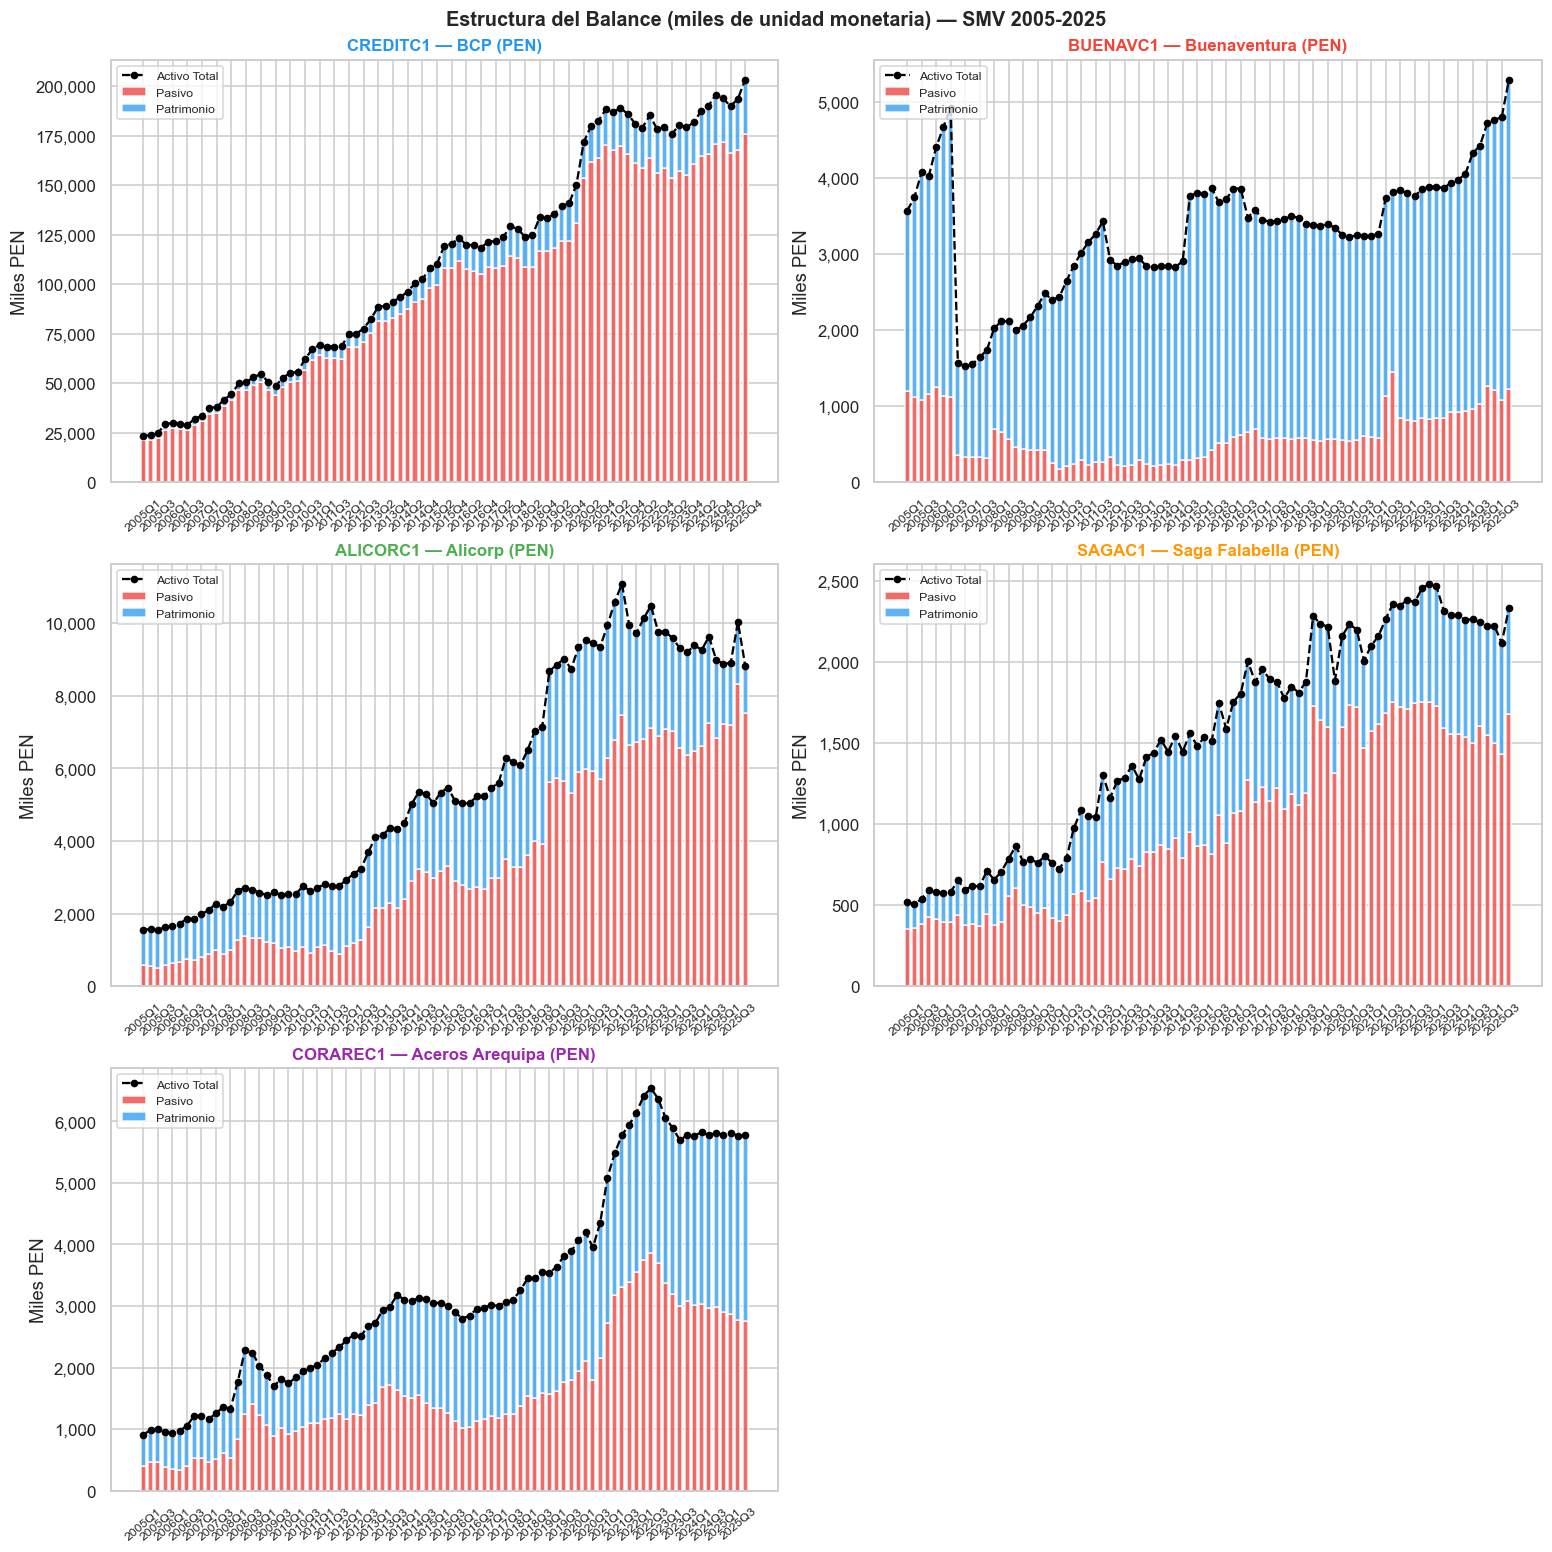

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14), constrained_layout=True)
axes_flat = axes.flatten()
fig.suptitle('Estructura del Balance (miles de unidad monetaria) — SMV 2005-2025',
             fontsize=13, fontweight='bold')

for i, ticker in enumerate(TICKERS):
    ax = axes_flat[i]
    df = fund.get(ticker)
    if df is None:
        ax.set_visible(False)
        continue
    sub = df[df['account'].isin(
        ['INFO_ActivoTotal', 'INFO_PasivoTotal', 'INFO_PatrimonioTotal'])].copy()
    sub['period'] = pd.to_datetime(sub['period'])
    pivot = sub.pivot_table(
        index='period', columns='account', values='value', aggfunc='first'
    ).sort_index()
    labels_x = [f"{p.year}Q{(p.month-1)//3+1}" for p in pivot.index]
    pivot_k = pivot / 1_000
    moneda = df['currency'].iloc[0]

    col_pas = 'INFO_PasivoTotal'
    col_pat = 'INFO_PatrimonioTotal'
    col_act = 'INFO_ActivoTotal'
    x = np.arange(len(pivot_k))

    if col_pas in pivot_k.columns:
        ax.bar(x, pivot_k[col_pas], label='Pasivo', color='#EF5350', alpha=0.85, width=0.7)
    bot = pivot_k.get(col_pas, pd.Series(0, index=pivot_k.index))
    if col_pat in pivot_k.columns:
        ax.bar(x, pivot_k[col_pat], bottom=bot, label='Patrimonio',
               color='#42A5F5', alpha=0.85, width=0.7)
    if col_act in pivot_k.columns:
        ax.plot(x, pivot_k[col_act], 'k--o', linewidth=1.5,
                markersize=4, label='Activo Total', zorder=5)

    ax.set_xticks(x[::2])
    ax.set_xticklabels(labels_x[::2], rotation=40, fontsize=8)
    ax.set_title(f'{ticker} — {NOMBRES[ticker]} ({moneda})',
                 fontweight='bold', color=COLOR_MAP[ticker])
    ax.set_ylabel(f'Miles {moneda}')
    ax.legend(fontsize=8, loc='upper left')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

axes_flat[-1].set_visible(False)
plt.show()

## 4. Cuenta de Resultados — Ingresos y Utilidad Neta

Los valores son **acumulados del ejercicio (YTD)** tal como los reporta la SMV, por lo que Q4 (diciembre) es el valor anual completo y Q1 es el más pequeño.

> Buenaventura reporta en **USD**. Su utilidad puede ser negativa en años de bajo precio del oro o por deterioro de activos.

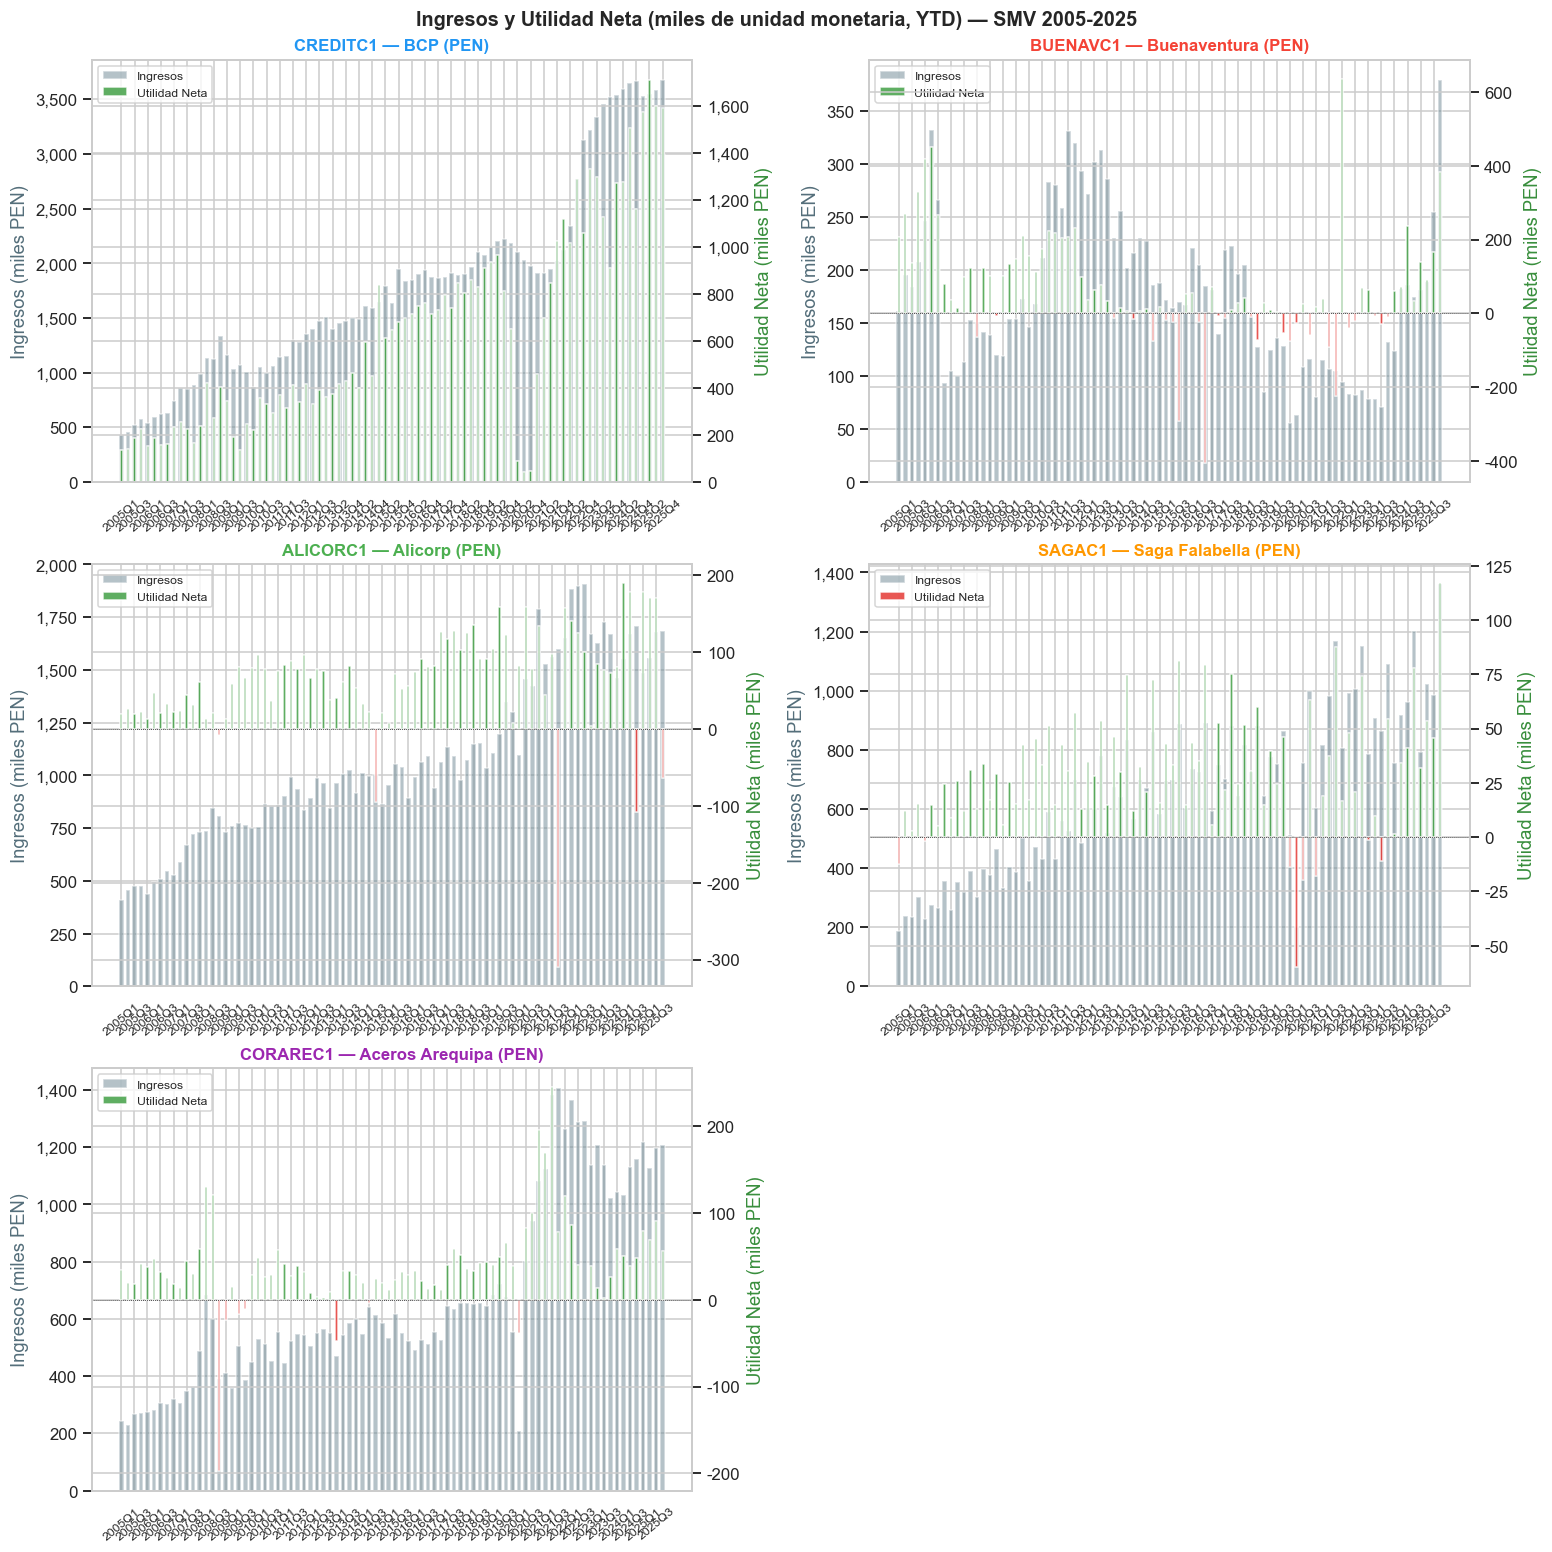

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14), constrained_layout=True)
axes_flat = axes.flatten()
fig.suptitle('Ingresos y Utilidad Neta (miles de unidad monetaria, YTD) — SMV 2005-2025',
             fontsize=13, fontweight='bold')

for i, ticker in enumerate(TICKERS):
    ax = axes_flat[i]
    df = fund.get(ticker)
    if df is None:
        ax.set_visible(False)
        continue
    sub = df[df['account'].isin(
        ['INFO_TotalIngreso', 'INFO_UtilidadNeta'])].copy()
    sub['period'] = pd.to_datetime(sub['period'])
    pivot = sub.pivot_table(
        index='period', columns='account', values='value', aggfunc='first'
    ).sort_index() / 1_000
    labels_x = [f"{p.year}Q{(p.month-1)//3+1}" for p in pivot.index]
    moneda = df['currency'].iloc[0]
    x = np.arange(len(pivot))

    ax2 = ax.twinx()
    if 'INFO_TotalIngreso' in pivot.columns:
        ax.bar(x, pivot['INFO_TotalIngreso'], color='#78909C',
               alpha=0.55, width=0.7, label='Ingresos')
    if 'INFO_UtilidadNeta' in pivot.columns:
        colors_bar = ['#43A047' if v >= 0 else '#E53935'
                      for v in pivot['INFO_UtilidadNeta']]
        ax2.bar(x + 0.0, pivot['INFO_UtilidadNeta'], color=colors_bar,
                alpha=0.85, width=0.35, label='Utilidad Neta')
        ax2.axhline(0, color='black', linewidth=0.5, linestyle=':')

    ax.set_xticks(x[::2])
    ax.set_xticklabels(labels_x[::2], rotation=40, fontsize=8)
    ax.set_title(f'{ticker} — {NOMBRES[ticker]} ({moneda})',
                 fontweight='bold', color=COLOR_MAP[ticker])
    ax.set_ylabel(f'Ingresos (miles {moneda})', color='#546E7A')
    ax2.set_ylabel(f'Utilidad Neta (miles {moneda})', color='#388E3C')
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc='upper left')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

axes_flat[-1].set_visible(False)
plt.show()

## 5. Ratios fundamentales — Evolución temporal

Ratios calculados directamente de `INFO_*` del SMV (no requieren número de acciones):

| Ratio | Fórmula | Interpretación |
|-------|---------|----------------|
| **ROE** | Utilidad Neta / Patrimonio | Rentabilidad sobre fondos propios |
| **ROA** | Utilidad Neta / Activo Total | Rentabilidad sobre activos |
| **Margen Neto** | Utilidad Neta / Total Ingresos | Eficiencia de conversión ventas→utilidad |
| **D/E** | Pasivo / Patrimonio | Apalancamiento financiero |
| **Debt Ratio** | Pasivo / Activo | Proporción de activos financiados con deuda |

In [6]:
ultimo_q = ratios.groupby('ticker').last().reset_index()[[
    'ticker', 'period', 'roe', 'roa', 'net_margin', 'debt_equity', 'debt_ratio'
]]
ultimo_q['period'] = ultimo_q['period'].dt.strftime('%Y-%m-%d')
ultimo_q = ultimo_q.set_index('ticker')
ultimo_q.columns.name = None

fmt = {'roe': '{:.2%}', 'roa': '{:.2%}', 'net_margin': '{:.2%}',
       'debt_equity': '{:.2f}×', 'debt_ratio': '{:.2%}'}

print('Ratios — último período disponible:')
ultimo_q.style.format({
    'roe':         '{:.2%}',
    'roa':         '{:.2%}',
    'net_margin':  '{:.2%}',
    'debt_equity': '{:.2f}',
    'debt_ratio':  '{:.2%}',
})

Ratios — último período disponible:


,period,roe,roa,net_margin,debt_equity,debt_ratio
ticker,,,,,,
ALICORC1,2025-12-31,-4.86%,-0.72%,-3.80%,5.70,85.07%
BUENAVC1,2025-12-31,9.44%,7.25%,101.10%,0.30,23.20%
CORAREC1,2025-12-31,1.87%,0.98%,4.67%,0.92,47.81%
CREDITC1,2025-12-31,5.82%,0.78%,43.23%,6.44,86.56%
SAGAC1,2025-12-31,17.94%,5.03%,8.60%,2.57,71.98%


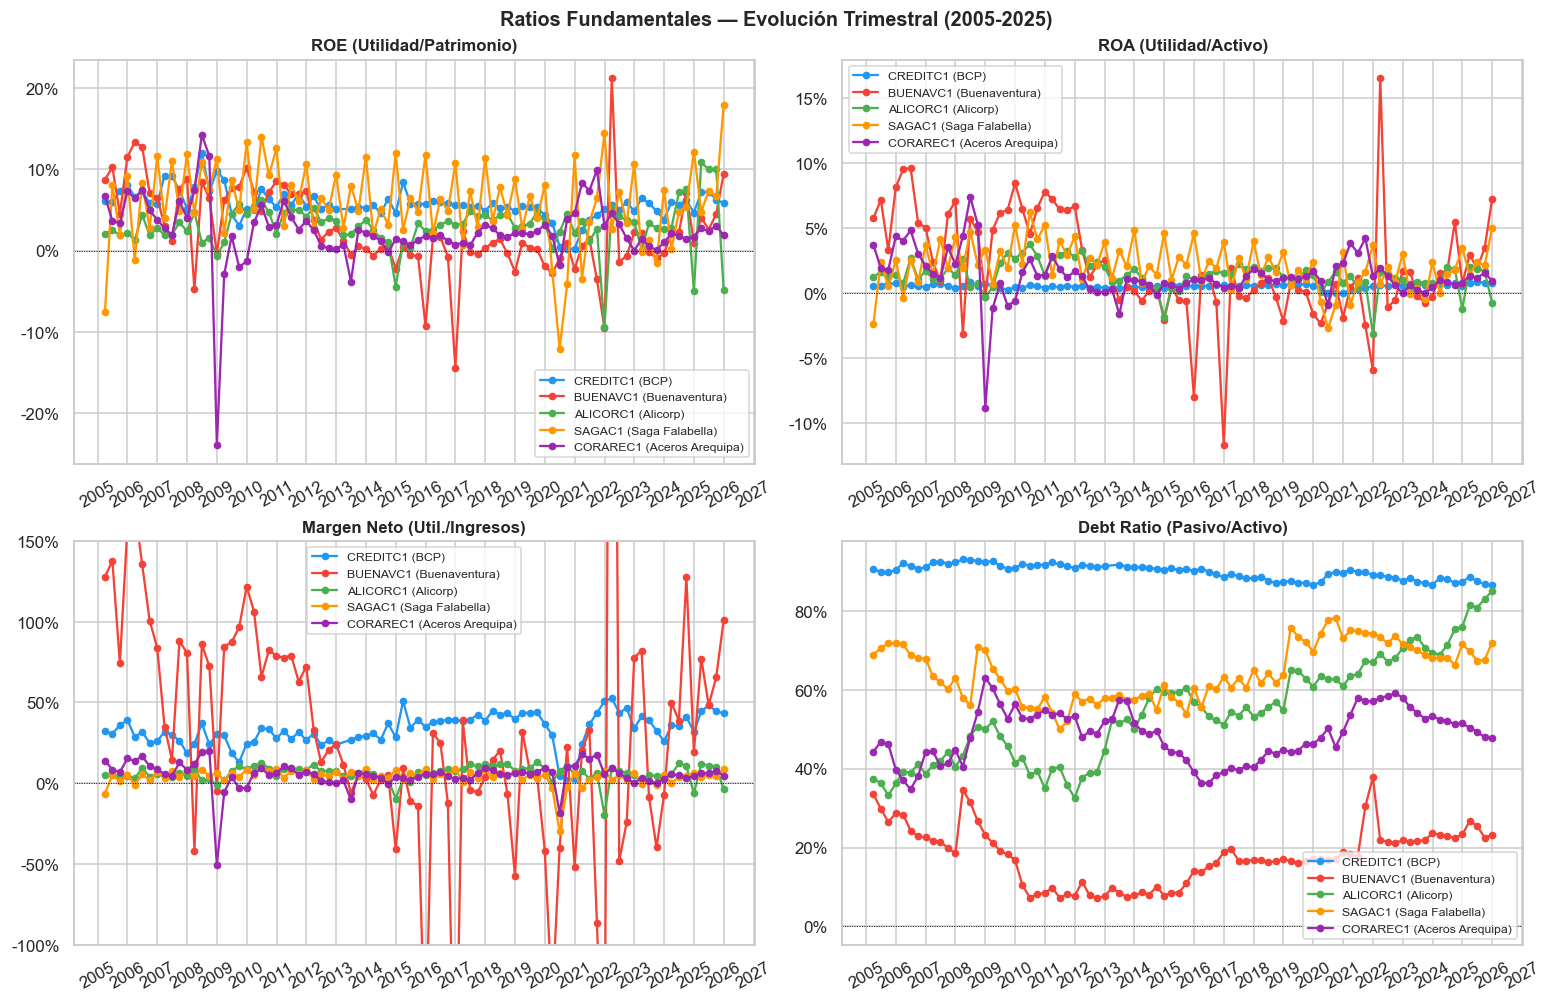

In [7]:
RATIO_META = [
    ('roe',         'ROE (Utilidad/Patrimonio)',    '{:.1%}',  None),
    ('roa',         'ROA (Utilidad/Activo)',        '{:.1%}',  None),
    ('net_margin',  'Margen Neto (Util./Ingresos)', '{:.1%}',  (-1.0, 1.5)),
    ('debt_ratio',  'Debt Ratio (Pasivo/Activo)',   '{:.0%}',  None),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes_flat = axes.flatten()
fig.suptitle('Ratios Fundamentales — Evolución Trimestral (2005-2025)',
             fontsize=13, fontweight='bold')

for ax, (col, title, fmt_str, ylim) in zip(axes_flat, RATIO_META):
    for ticker, color in zip(TICKERS, COLORES):
        sub = ratios[ratios['ticker'] == ticker].sort_values('period')
        if sub.empty or col not in sub.columns:
            continue
        ax.plot(sub['period'], sub[col],
                label=f'{ticker} ({NOMBRES[ticker]})',
                color=color, linewidth=1.5, marker='o', markersize=4)
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _: fmt_str.format(v)))
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8, loc='best')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.show()

## 5b. Acciones en circulación, EPS TTM y valoración (P/E, DY)

Serie histórica de **acciones en circulación** reconstruida como `(Capital Emitido − Acciones en Cartera) / valor nominal` (SMV), con el `quantity` de la BVL como ancla y validación (coinciden al dígito en 4/5) y el ancla SEC 20-F para BUENAVC1 (capital en USD sin nominal limpio → constante 253.72M). A partir de ahí:

- **P/E** = `close_raw × acciones / UtilidadNeta_TTM` = capitalización / utilidad TTM (invariante a splits; se usa `close_raw`, no `close_split_adj`).
- **DY** = dividendos por acción TTM (PEN, fuente BVL R3) / `close_raw`.

P/E y DY son ratios **diarios** y viven en el panel unificado R6 (`data/processed/dataset_unificado.parquet`); aquí se grafican desde ese panel. Metodología y validación: docs/pipeline §3.10.2, hallazgos R4 §5.9.

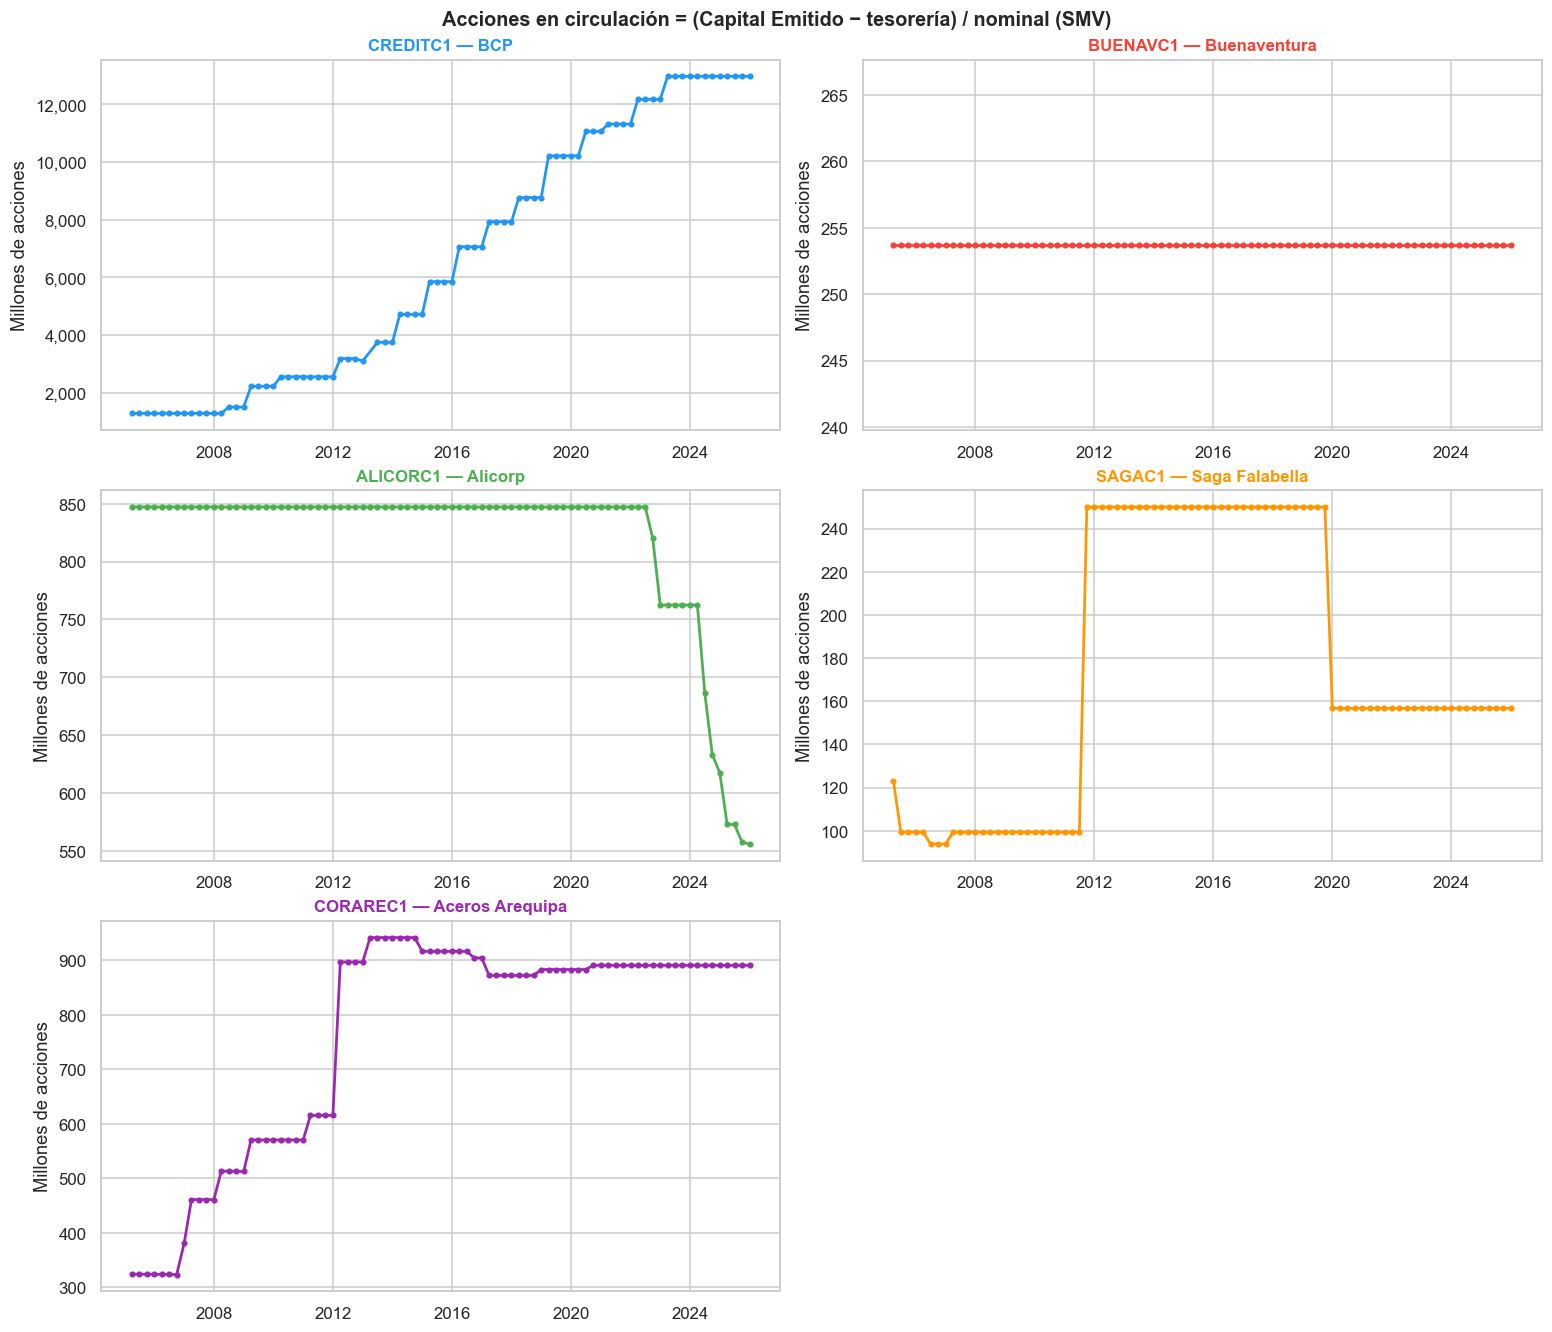

In [8]:
# Acciones en circulación reconstruidas (trimestral)
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
axf = axes.flatten()
fig.suptitle('Acciones en circulación = (Capital Emitido − tesorería) / nominal (SMV)',
             fontsize=13, fontweight='bold')
for i, ticker in enumerate(TICKERS):
    ax = axf[i]
    s = ratios[ratios['ticker'] == ticker].sort_values('period')
    if s.empty or 'shares_outstanding' not in s.columns:
        ax.set_visible(False); continue
    ax.plot(s['period'], s['shares_outstanding'] / 1e6,
            color=COLOR_MAP[ticker], linewidth=1.8, marker='o', markersize=3)
    ax.set_title(f'{ticker} — {NOMBRES[ticker]}', fontweight='bold', color=COLOR_MAP[ticker])
    ax.set_ylabel('Millones de acciones')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axf[-1].set_visible(False)
plt.show()

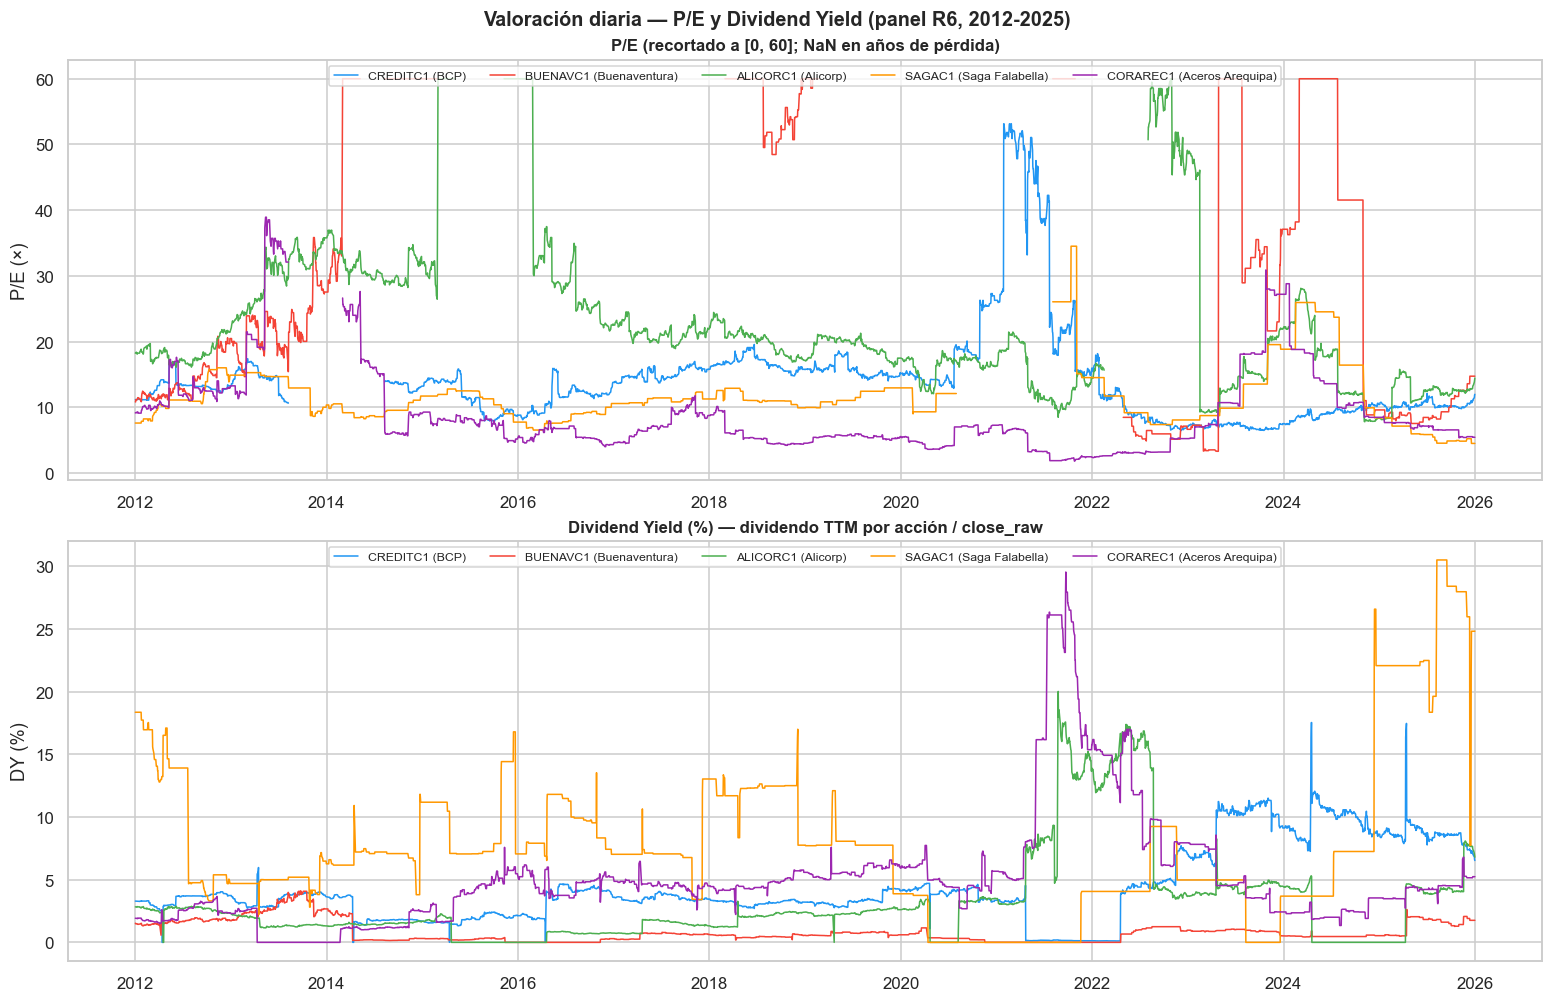

In [9]:
# P/E y DY diarios desde el panel unificado R6
panel = pd.read_parquet('../data/processed/dataset_unificado.parquet')
fig, (axpe, axdy) = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
fig.suptitle('Valoración diaria — P/E y Dividend Yield (panel R6, 2012-2025)',
             fontsize=13, fontweight='bold')
for ticker in TICKERS:
    g = panel[panel['ticker'] == ticker].sort_values('date')
    if g.empty:
        continue
    axpe.plot(g['date'], g['pe'].clip(lower=0, upper=60),
              label=f'{ticker} ({NOMBRES[ticker]})', color=COLOR_MAP[ticker], linewidth=1.0)
    axdy.plot(g['date'], g['dy'] * 100,
              label=f'{ticker} ({NOMBRES[ticker]})', color=COLOR_MAP[ticker], linewidth=1.0)
axpe.set_title('P/E (recortado a [0, 60]; NaN en años de pérdida)', fontweight='bold')
axpe.set_ylabel('P/E (×)')
axpe.legend(fontsize=8, ncol=5, loc='upper center')
axdy.set_title('Dividend Yield (%) — dividendo TTM por acción / close_raw', fontweight='bold')
axdy.set_ylabel('DY (%)')
axdy.legend(fontsize=8, ncol=5, loc='upper center')
for ax in (axpe, axdy):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.show()

## 6. Comparativa entre empresas — Último trimestre disponible

Comparación side-by-side de ratios para el último período disponible.
BUENAVC1 se muestra con moneda diferente (USD); los ratios son adimensionales y por tanto comparables entre monedas.

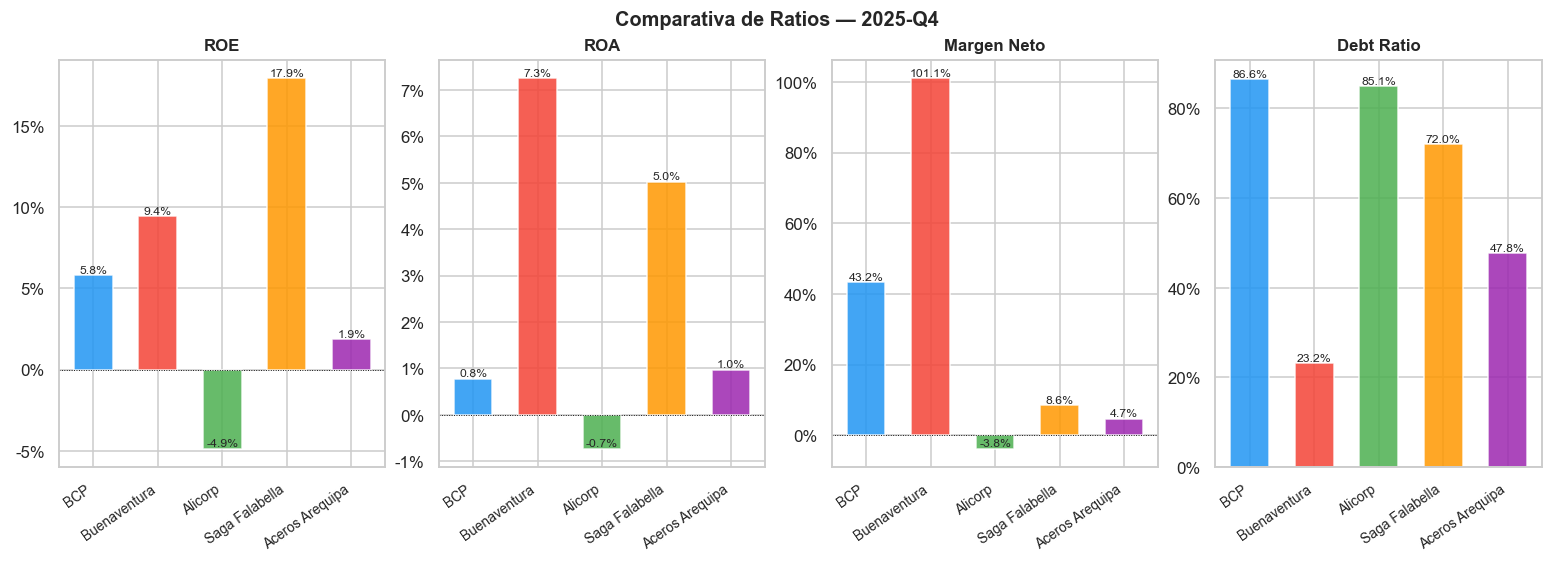

In [10]:
ult = ratios[ratios['period'] == ratios['period'].max()].set_index('ticker')

ratios_plot = ['roe', 'roa', 'net_margin', 'debt_ratio']
labels_plot = ['ROE', 'ROA', 'Margen Neto', 'Debt Ratio']

fig, axes = plt.subplots(1, len(ratios_plot), figsize=(14, 5), constrained_layout=True)
fig.suptitle(f'Comparativa de Ratios — {ult["period"].iloc[0].strftime("%Y-Q4")}',
             fontsize=13, fontweight='bold')

for ax, col, label in zip(axes, ratios_plot, labels_plot):
    vals = [ult.loc[t, col] if t in ult.index else np.nan for t in TICKERS]
    bar_colors = [COLOR_MAP[t] for t in TICKERS]
    bars = ax.bar(range(len(TICKERS)), vals, color=bar_colors, alpha=0.85, width=0.6)
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(len(TICKERS)))
    ax.set_xticklabels([NOMBRES[t] for t in TICKERS], rotation=35,
                       ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        if np.isfinite(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.1%}', ha='center', va='bottom', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.show()

## 7. Heatmap de ratios — todas las empresas × todos los períodos

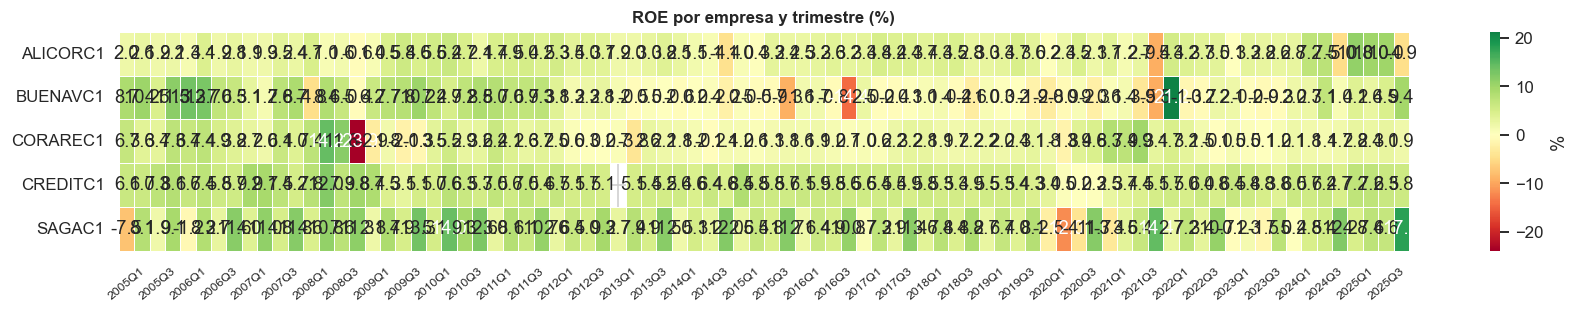

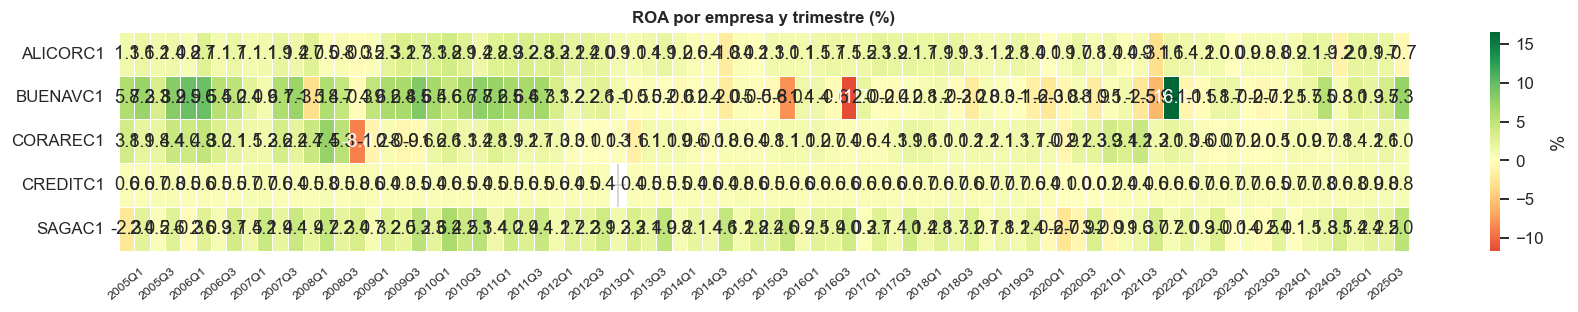

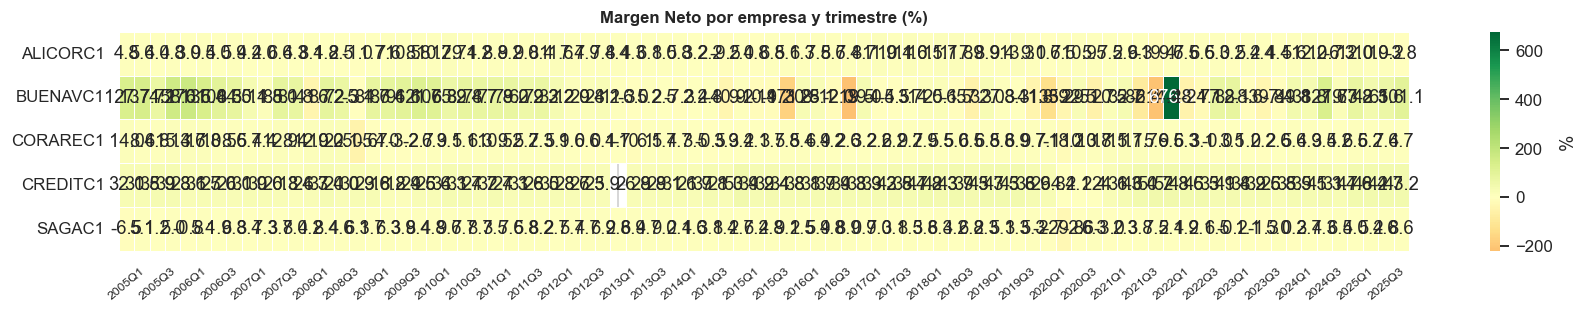

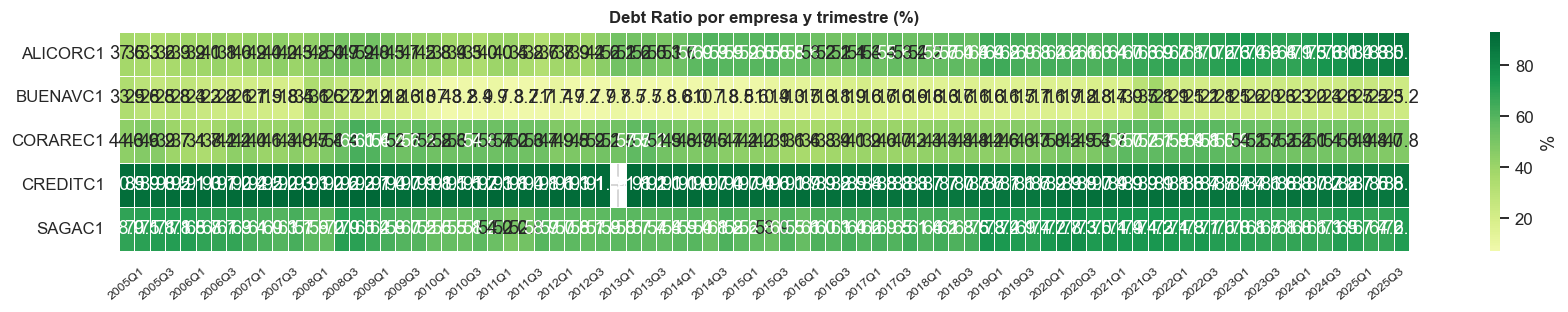

In [11]:
for col, title in [('roe', 'ROE'), ('roa', 'ROA'),
                   ('net_margin', 'Margen Neto'), ('debt_ratio', 'Debt Ratio')]:
    pivot_heat = ratios.pivot_table(
        index='ticker', columns='period', values=col, aggfunc='first')
    pivot_heat.columns = [
        f"{p.year}Q{(p.month-1)//3+1}" for p in pivot_heat.columns]

    fig, ax = plt.subplots(figsize=(16, 3))
    sns.heatmap(pivot_heat * 100, annot=True, fmt='.1f',
                cmap='RdYlGn', center=0,
                linewidths=0.4, ax=ax, cbar_kws={'label': '%'})
    ax.set_title(f'{title} por empresa y trimestre (%)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=40, fontsize=8)
    plt.tight_layout()
    plt.show()

## 8. Vista de datos crudos (formato largo)

Muestra las primeras filas de cada parquet en el esquema canónico `FUNDAMENTALS_SCHEMA`.

In [12]:
for ticker, df in fund.items():
    print(f'\n=== {ticker} ({NOMBRES[ticker]}) — {len(df)} filas ===')
    info_rows = df[df['account'].str.startswith('INFO_')].copy()
    info_rows['period'] = pd.to_datetime(info_rows['period'])
    info_rows = info_rows.sort_values('period')
    display(info_rows.tail(10))


=== CREDITC1 (BCP) — 22425 filas ===


,ticker,period,known_date,account,value,currency,source
21906,CREDITC1,2025-09-30,2025-10-23,INFO_UtilidadNeta,1601381.0,PEN,smv
21905,CREDITC1,2025-09-30,2025-10-23,INFO_TotalIngreso,3585064.0,PEN,smv
21907,CREDITC1,2025-09-30,2025-10-23,INFO_PasivoTotal,167953871.0,PEN,smv
21903,CREDITC1,2025-09-30,2025-10-23,INFO_ActivoTotal,193532778.0,PEN,smv
21904,CREDITC1,2025-09-30,2025-10-23,INFO_PatrimonioTotal,25578907.0,PEN,smv
22166,CREDITC1,2025-12-31,2026-03-01,INFO_TotalIngreso,3677901.0,PEN,smv
22167,CREDITC1,2025-12-31,2026-03-01,INFO_UtilidadNeta,1590028.0,PEN,smv
22164,CREDITC1,2025-12-31,2026-03-01,INFO_ActivoTotal,203228048.0,PEN,smv
22165,CREDITC1,2025-12-31,2026-03-01,INFO_PatrimonioTotal,27317141.0,PEN,smv
22168,CREDITC1,2025-12-31,2026-03-01,INFO_PasivoTotal,175910907.0,PEN,smv



=== BUENAVC1 (Buenaventura) — 17928 filas ===


,ticker,period,known_date,account,value,currency,source
17500,BUENAVC1,2025-09-30,2025-10-31,INFO_ActivoTotal,4795282.0,USD,smv
17501,BUENAVC1,2025-09-30,2025-10-31,INFO_PatrimonioTotal,3715014.0,USD,smv
17502,BUENAVC1,2025-09-30,2025-10-31,INFO_TotalIngreso,254970.0,USD,smv
17503,BUENAVC1,2025-09-30,2025-10-31,INFO_UtilidadNeta,167149.0,USD,smv
17504,BUENAVC1,2025-09-30,2025-10-31,INFO_PasivoTotal,1080268.0,USD,smv
17717,BUENAVC1,2025-12-31,2026-03-01,INFO_UtilidadNeta,383605.0,USD,smv
17714,BUENAVC1,2025-12-31,2026-03-01,INFO_ActivoTotal,5288978.0,USD,smv
17715,BUENAVC1,2025-12-31,2026-03-01,INFO_PatrimonioTotal,4061890.0,USD,smv
17716,BUENAVC1,2025-12-31,2026-03-01,INFO_TotalIngreso,379417.0,USD,smv
17718,BUENAVC1,2025-12-31,2026-03-01,INFO_PasivoTotal,1227088.0,USD,smv



=== ALICORC1 (Alicorp) — 17928 filas ===


,ticker,period,known_date,account,value,currency,source
17500,ALICORC1,2025-09-30,2025-10-31,INFO_ActivoTotal,10018191.0,PEN,smv
17501,ALICORC1,2025-09-30,2025-10-31,INFO_PatrimonioTotal,1706274.0,PEN,smv
17502,ALICORC1,2025-09-30,2025-10-31,INFO_TotalIngreso,1680428.0,PEN,smv
17503,ALICORC1,2025-09-30,2025-10-31,INFO_UtilidadNeta,171148.0,PEN,smv
17504,ALICORC1,2025-09-30,2025-10-31,INFO_PasivoTotal,8311917.0,PEN,smv
17717,ALICORC1,2025-12-31,2026-03-01,INFO_UtilidadNeta,-63955.0,USD,smv
17714,ALICORC1,2025-12-31,2026-03-01,INFO_ActivoTotal,8823663.0,USD,smv
17715,ALICORC1,2025-12-31,2026-03-01,INFO_PatrimonioTotal,1317071.0,USD,smv
17716,ALICORC1,2025-12-31,2026-03-01,INFO_TotalIngreso,1682558.0,USD,smv
17718,ALICORC1,2025-12-31,2026-03-01,INFO_PasivoTotal,7506592.0,USD,smv



=== SAGAC1 (Saga Falabella) — 17928 filas ===


,ticker,period,known_date,account,value,currency,source
17500,SAGAC1,2025-09-30,2025-11-01,INFO_ActivoTotal,2115719.0,PEN,smv
17501,SAGAC1,2025-09-30,2025-11-01,INFO_PatrimonioTotal,684993.0,PEN,smv
17502,SAGAC1,2025-09-30,2025-11-01,INFO_TotalIngreso,984054.0,PEN,smv
17503,SAGAC1,2025-09-30,2025-11-01,INFO_UtilidadNeta,45544.0,PEN,smv
17504,SAGAC1,2025-09-30,2025-11-01,INFO_PasivoTotal,1430726.0,PEN,smv
17717,SAGAC1,2025-12-31,2026-03-01,INFO_UtilidadNeta,117057.0,PEN,smv
17714,SAGAC1,2025-12-31,2026-03-01,INFO_ActivoTotal,2329156.0,PEN,smv
17715,SAGAC1,2025-12-31,2026-03-01,INFO_PatrimonioTotal,652593.0,PEN,smv
17716,SAGAC1,2025-12-31,2026-03-01,INFO_TotalIngreso,1360795.0,PEN,smv
17718,SAGAC1,2025-12-31,2026-03-01,INFO_PasivoTotal,1676563.0,PEN,smv



=== CORAREC1 (Aceros Arequipa) — 17924 filas ===


,ticker,period,known_date,account,value,currency,source
17496,CORAREC1,2025-09-30,2025-10-31,INFO_ActivoTotal,5769058.0,PEN,smv
17497,CORAREC1,2025-09-30,2025-10-31,INFO_PatrimonioTotal,3002139.0,PEN,smv
17498,CORAREC1,2025-09-30,2025-10-31,INFO_TotalIngreso,1198804.0,PEN,smv
17499,CORAREC1,2025-09-30,2025-10-31,INFO_UtilidadNeta,90986.0,PEN,smv
17500,CORAREC1,2025-09-30,2025-10-31,INFO_PasivoTotal,2766919.0,PEN,smv
17713,CORAREC1,2025-12-31,2026-03-01,INFO_UtilidadNeta,56405.0,PEN,smv
17710,CORAREC1,2025-12-31,2026-03-01,INFO_ActivoTotal,5771493.0,PEN,smv
17711,CORAREC1,2025-12-31,2026-03-01,INFO_PatrimonioTotal,3012236.0,PEN,smv
17712,CORAREC1,2025-12-31,2026-03-01,INFO_TotalIngreso,1206936.0,PEN,smv
17714,CORAREC1,2025-12-31,2026-03-01,INFO_PasivoTotal,2759257.0,PEN,smv
